In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## IMPORT LIBRARY

In [ ]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from skimage.feature import graycomatrix, graycoprops
from skimage.color import rgb2gray

from google.colab import drive, files
from tensorflow.keras.models import load_model
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

## PREPROCESSING CITRA

In [ ]:
IMG_SIZE = 224

def preprocess_image(img_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img / 255.0
    return img

## EKSTRAKSI FITUR TEKSTUR (GLCM)

In [ ]:
def extract_glcm_features(img):
    gray = rgb2gray(img)
    gray = (gray * 255).astype(np.uint8)

    glcm = graycomatrix(
        gray,
        distances=[1],
        angles=[0],
        levels=256,
        symmetric=True,
        normed=True
    )

    return [
        graycoprops(glcm, 'contrast')[0,0],
        graycoprops(glcm, 'correlation')[0,0],
        graycoprops(glcm, 'energy')[0,0],
        graycoprops(glcm, 'homogeneity')[0,0]
    ]

## EKSTRAKSI FITUR WARNA (HSV)

In [ ]:
def extract_hsv_features(img):
    hsv = cv2.cvtColor((img * 255).astype(np.uint8), cv2.COLOR_RGB2HSV)
    h, s, v = cv2.split(hsv)

    return [
        np.mean(h), np.std(h),
        np.mean(s), np.std(s),
        np.mean(v), np.std(v)
    ]

## GABUNG FITUR (GLCM + HSV)

In [ ]:
def extract_features(img_path):
    img = preprocess_image(img_path)
    glcm_feat = extract_glcm_features(img)
    hsv_feat = extract_hsv_features(img)
    return np.concatenate([glcm_feat, hsv_feat])

## LOAD DATASET (TRAIN & TEST)

In [ ]:
def load_dataset(base_path):
    X_img, X_feat, y = [], [], []

    class_map = {
        "haid": 0,
        "istihadoh": 1
    }

    valid_ext = ('.jpg', '.jpeg', '.png')

    for class_name, label in class_map.items():
        folder = os.path.join(base_path, class_name)

        for file in os.listdir(folder):
            if not file.lower().endswith(valid_ext):
                continue

            img_path = os.path.join(folder, file)

            try:
                img = preprocess_image(img_path)
                feat = extract_features(img_path)

                X_img.append(img)
                X_feat.append(feat)
                y.append(label)

            except Exception as e:
                print("Error:", img_path, e)

    return (
        np.array(X_img, dtype=np.float32),
        np.array(X_feat, dtype=np.float32),
        np.array(y, dtype=np.int32)
    )

In [ ]:
TRAIN_PATH = "/content/drive/MyDrive/Dataset/dataset_citra_darah_haid_istihadoh_4000/train"
TEST_PATH  = "/content/drive/MyDrive/Dataset/dataset_citra_darah_haid_istihadoh_4000/test"

## LOAD TRAIN & TEST

In [ ]:
X_img_train, X_feat_train, y_train = load_dataset(TRAIN_PATH)
X_img_test, X_feat_test, y_test = load_dataset(TEST_PATH)

print(X_img_train.shape)
print(X_feat_train.shape)
print(y_train.shape)

(3201, 224, 224, 3)
(3201, 10)
(3201,)


## NORMALISASI FITUR GLCM + HSV

In [ ]:
scaler = StandardScaler()

X_feat_train = scaler.fit_transform(X_feat_train)
X_feat_test  = scaler.transform(X_feat_test)

In [ ]:
# ==== DETEKSI WAJAH (ANTI SELFIE) ====
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

def contains_face(img_path):
    img = cv2.imread(img_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    return len(faces) > 0


# ==== VALIDASI CITRA DARAH (KETAT) ====
def is_blood_image(img_path):
    # 1. Jika ada wajah → BUKAN darah
    if contains_face(img_path):
        return False

    img = cv2.imread(img_path)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # 2. Warna merah gelap khas darah
    mask = (
        ((h < 8) | (h > 170)) &   # merah sempit
        (s > 120) &               # saturasi tinggi
        (v > 50) & (v < 180)      # merah gelap
    )

    blood_ratio = np.sum(mask) / (img.shape[0] * img.shape[1])

    # 3. Minimal 3% area darah
    return blood_ratio > 0.03

## HITUNG CLASS WEIGHT

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(1.0003125), 1: np.float64(0.9996876951905059)}


## MODEL HYBRID CNN + GLCM-HSV

In [ ]:
from tensorflow.keras import layers, models

cnn_input = layers.Input(shape=(224,224,3))

x = layers.Conv2D(32, (3,3), activation='relu')(cnn_input)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)

feature_input = layers.Input(shape=(10,))

merged = layers.concatenate([x, feature_input])
merged = layers.Dense(64, activation='relu')(merged)
merged = layers.Dropout(0.3)(merged)

output = layers.Dense(1, activation='sigmoid')(merged)

model = models.Model(
    inputs=[cnn_input, feature_input],
    outputs=output
)

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 111,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 54, 54,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling2d_1[… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 74)        │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 64)        │      4,800 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1)         │         65 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,257 (94.75 KB)

 Trainable params: 24,257 (94.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
def predict_with_unknown(img_path):
    # ===============================
    # STEP 1: VALIDASI DOMAIN
    # ===============================
    if not is_blood_image(img_path):
        return {
            "label": "UNKNOWN",
            "message": "Silakan upload citra darah untuk dilakukan analisis",
            "confidence": 0.0,
            "icd10": "-"
        }

    # ===============================
    # STEP 2: PREPROCESSING & FITUR
    # ===============================
    img = preprocess_image(img_path)
    feat = extract_features(img_path)

    img = np.expand_dims(img, axis=0)
    feat = np.expand_dims(feat, axis=0)

    prob = model.predict([img, feat])[0][0]

    # ===============================
    # STEP 3: THRESHOLDING
    # ===============================
    if prob < 0.35:
        return {
            "label": "HAID NORMAL",
            "message": "Citra darah terdeteksi",
            "confidence": (1 - prob) * 100,
            "icd10": "Z30.9"
        }
    elif prob > 0.65:
        return {
            "label": "ISTIHADA (AUB)",
            "message": "Citra darah terdeteksi",
            "confidence": prob * 100,
            "icd10": "N93.9"
        }
    else:
        return {
            "label": "UNKNOWN",
            "message": "Citra darah terdeteksi, namun tidak dapat diklasifikasikan dengan yakin",
            "confidence": prob * 100,
            "icd10": "-"
        }

## TRAINING MODEL

In [ ]:
model.fit(
    [X_img_train, X_feat_train],
    y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.1,
    class_weight=class_weights
)

Epoch 1/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 212s 584ms/step - accuracy: 0.8845 - loss: 0.2533 - val_accuracy: 1.0000 - val_loss: 9.1157e-04
Epoch 2/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 215s 598ms/step - accuracy: 0.9982 - loss: 0.0060 - val_accuracy: 1.0000 - val_loss: 3.0789e-04
Epoch 3/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 261s 596ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 1.0000 - val_loss: 1.9129e-05
Epoch 4/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 254s 575ms/step - accuracy: 1.0000 - loss: 2.2061e-04 - val_accuracy: 1.0000 - val_loss: 7.8678e-06
Epoch 5/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 267s 589ms/step - accuracy: 1.0000 - loss: 2.4780e-04 - val_accuracy: 1.0000 - val_loss: 1.4552e-04
Epoch 6/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 211s 586ms/step - accuracy: 1.0000 - loss: 2.8383e-04 - val_accuracy: 1.0000 - val_loss: 1.1292e-05
Epoch 7/30
360/360 ━━━━━━━━━━━━━━━━━━━━ 260s 580ms/step - accuracy: 1.0000 - loss: 1.4357e-04 - val_accuracy: 1.0000 - val_loss: 2.0042e-06
Epoch 8/30
360/360 ━━━━━━━━━━━━━

## EVALUASI (CONFUSION MATRIX)

In [ ]:
y_pred = model.predict([X_img_test, X_feat_test])
y_pred = (y_pred > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["Haid", "Istihada"]))

26/26 ━━━━━━━━━━━━━━━━━━━━ 20s 709ms/step
[[400   0]
 [  0 401]]
              precision    recall  f1-score   support

        Haid       1.00      1.00      1.00       400
    Istihada       1.00      1.00      1.00       401

    accuracy                           1.00       801
   macro avg       1.00      1.00      1.00       801
weighted avg       1.00      1.00      1.00       801



In [ ]:
# Probabilitas prediksi (untuk ROC)
y_prob = model.predict([X_img_test, X_feat_test]).ravel()

# Prediksi kelas (untuk confusion matrix)
y_pred = (y_prob >= 0.5).astype(int)

26/26 ━━━━━━━━━━━━━━━━━━━━ 18s 674ms/step


## SIMPAN MODEL

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/model_aub_cnn_glcm_hsv.h5"
model.save(MODEL_PATH)
print("Model disimpan:", MODEL_PATH)

Model disimpan: /content/drive/MyDrive/model_aub_cnn_glcm_hsv.h5


## PREDIKSI DATA BARU

Saving a947fa98e053678fc460aa7d95071c22.jpg to a947fa98e053678fc460aa7d95071c22.jpg
               HASIL UJI GAMBAR              
---------------------------------------------
Diagnosis        : UNKNOWN
Probabilitas     : 0.00%
ICD-10           : -


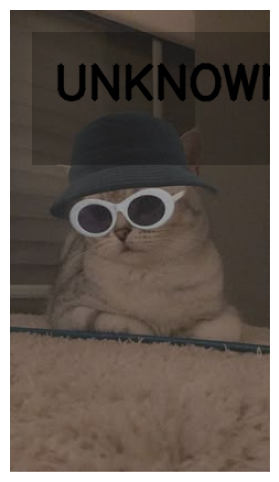

In [ ]:
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

result = predict_with_unknown(img_path)

print("="*45)
print("HASIL UJI GAMBAR".center(45))
print("-"*45)
print(f"Diagnosis        : {result['label']}")
print(f"Probabilitas     : {result['confidence']:.2f}%")
print(f"ICD-10           : {result['icd10']}")
print("="*45)

# tampilkan gambar + overlay
img_disp = cv2.imread(img_path)
img_disp = cv2.cvtColor(img_disp, cv2.COLOR_BGR2RGB)

color_map = {
    "ISTIHADA (AUB)": (220, 20, 60),
    "HAID NORMAL": (34, 139, 34),
    "UNKNOWN (BUKAN CITRA DARAH)": (105, 105, 105),
    "UNKNOWN (TIDAK YAKIN)": (255, 165, 0)
}

color = color_map.get(result["label"], (0,0,0))

overlay = img_disp.copy()
cv2.rectangle(overlay, (20, 20), (700, 140), color, -1)
img_disp = cv2.addWeighted(overlay, 0.25, img_disp, 0.75, 0)

cv2.putText(
    img_disp,
    result["label"],
    (40, 80),
    cv2.FONT_HERSHEY_SIMPLEX,
    1.4,
    color,
    4,
    cv2.LINE_AA
)

plt.figure(figsize=(8,6))
plt.imshow(img_disp)
plt.axis("off")
plt.show()

## UJI HL7 FHIR (VALIDASI FUNGSIONAL)

In [ ]:
import requests

FHIR_URL = "https://hapi.fhir.org/baseR4/Observation"

data = {
  "resourceType": "Observation",
  "status": "final",
  "code": {
    "coding": [{
      "system": "http://hl7.org/fhir/sid/icd-10",
      "code": "N93.9",
      "display": "Abnormal uterine bleeding"
    }]
  },
  "valueString": "Istihada terdeteksi oleh sistem AI"
}

response = requests.post(FHIR_URL, json=data)
print("FHIR Status:", response.status_code)

FHIR Status: 500


In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

print("TP:", tp)
print("FP:", fp)
print("FN:", fn)
print("TN:", tn)

TP: 401
FP: 0
FN: 0
TN: 400


In [ ]:
import math
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
n = tp + tn + fp + fn
z = 1.96

ci_lower = accuracy - z * math.sqrt((accuracy * (1 - accuracy)) / n)
ci_upper = accuracy + z * math.sqrt((accuracy * (1 - accuracy)) / n)

print(f"Akurasi : {accuracy:.4f}")
print(f"95% CI  : ({ci_lower:.4f}, {ci_upper:.4f})")

Akurasi : 1.0000
95% CI  : (1.0000, 1.0000)


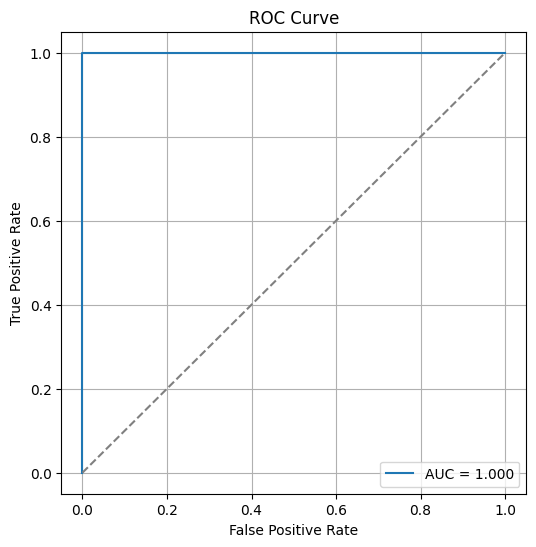

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import matthews_corrcoef

mcc = matthews_corrcoef(y_test, y_pred)
print("MCC:", mcc)

MCC: 1.0
